# Fase 2: Comparació de modes d'entrenament PPO amb Cos pre-entrenat

Comparem 3 estratègies d'ús del **Cos** (feature extractor pre-entrenat amb SL) dins l'entrenament PPO:

| Mode | Descripció |
|------|-----------|
| **Scratch** | Cos aleatori, tot entrena des de zero |
| **Frozen** | Cos SL pre-entrenat, congelat durant tot l'RL |
| **Finetune** | Cos SL pre-entrenat, congelat inicialment, descongelat al 15% dels timesteps |

**Condicions**: 48 entorns paral·lels, 24M timesteps, oponents mixtos (5% Random, 65% Regles, 30% Self-play).  
**Mètrica**: `0.25 × WR_random + 0.75 × WR_regles`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BASE = Path("resultats_fase2_31_03_1839h")
if not BASE.exists():
    BASE = Path(r"c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\2_comparacio_cos\resultats_fase2_31_03_1839h")
BASE = BASE.resolve()

modes = {
    'Scratch':  ('scratch',  '#e74c3c'),
    'Frozen':   ('frozen',   '#3498db'),
    'Finetune': ('finetune', '#2ecc71'),
}

dfs = {}
for label, (folder, _) in modes.items():
    df = pd.read_csv(BASE / folder / "training_log.csv")
    df['step_M'] = df['step'] / 1e6
    dfs[label] = df

print("Columnes:", list(dfs['Scratch'].columns))
print(f"Files per mode: {len(dfs['Scratch'])}")
print(f"Rang steps: {dfs['Scratch']['step'].min()/1e6:.1f}M - {dfs['Scratch']['step'].max()/1e6:.1f}M")

## 1. Evolució de la mètrica combinada

`eval_metric = 0.25 × WR_random + 0.75 × WR_regles`

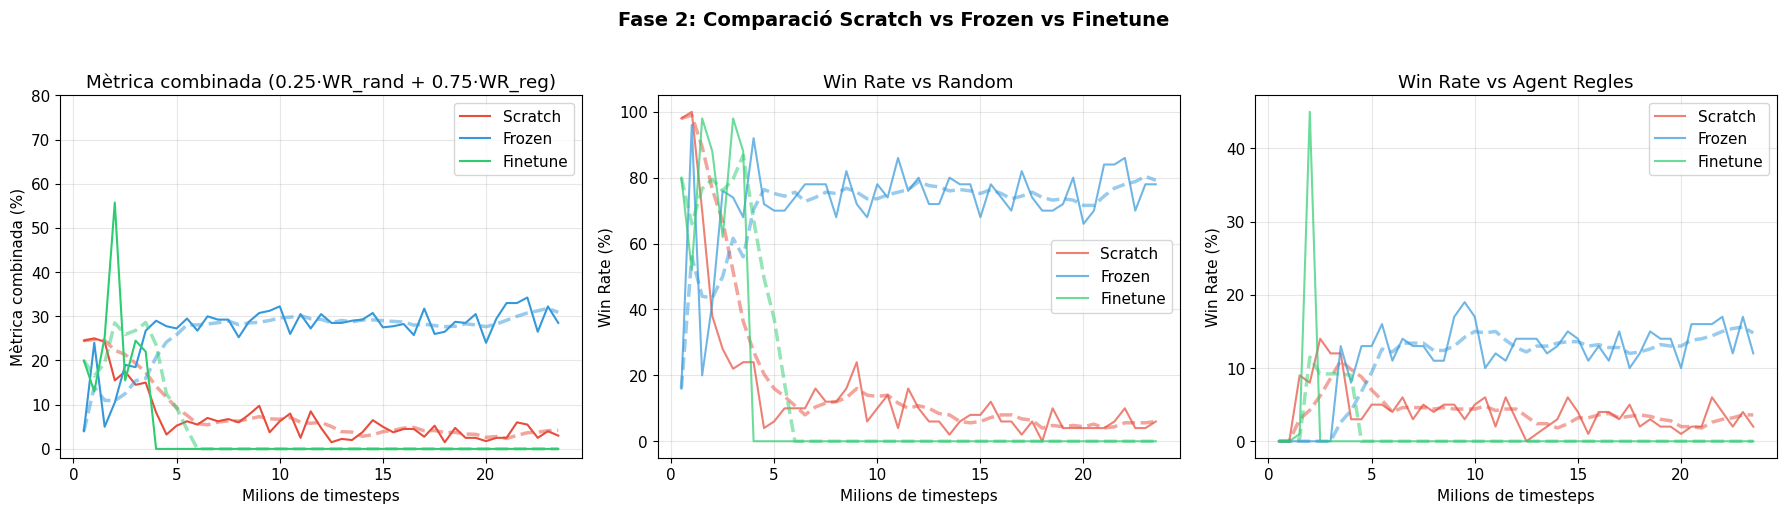

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Mètrica combinada ---
ax = axes[0]
for label, (_, color) in modes.items():
    df = dfs[label]
    ax.plot(df['step_M'], df['eval_metric'], color=color, label=label, linewidth=1.5)
    # Mitjana mòbil (finestra 5)
    rolling = df['eval_metric'].rolling(5, min_periods=1).mean()
    ax.plot(df['step_M'], rolling, color=color, linewidth=2.5, alpha=0.5, linestyle='--')
ax.set_xlabel('Milions de timesteps')
ax.set_ylabel('Mètrica combinada (%)')
ax.set_title('Mètrica combinada (0.25·WR_rand + 0.75·WR_reg)')
ax.legend()
ax.set_ylim(-2, 80)

# --- WR Random ---
ax = axes[1]
for label, (_, color) in modes.items():
    df = dfs[label]
    ax.plot(df['step_M'], df['eval_wr_random'], color=color, label=label, linewidth=1.5, alpha=0.7)
    rolling = df['eval_wr_random'].rolling(5, min_periods=1).mean()
    ax.plot(df['step_M'], rolling, color=color, linewidth=2.5, alpha=0.5, linestyle='--')
ax.set_xlabel('Milions de timesteps')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate vs Random')
ax.legend()

# --- WR Regles ---
ax = axes[2]
for label, (_, color) in modes.items():
    df = dfs[label]
    ax.plot(df['step_M'], df['eval_wr_regles'], color=color, label=label, linewidth=1.5, alpha=0.7)
    rolling = df['eval_wr_regles'].rolling(5, min_periods=1).mean()
    ax.plot(df['step_M'], rolling, color=color, linewidth=2.5, alpha=0.5, linestyle='--')
ax.set_xlabel('Milions de timesteps')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate vs Agent Regles')
ax.legend()

plt.suptitle('Fase 2: Comparació Scratch vs Frozen vs Finetune', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Evolució de la pèrdua (loss)

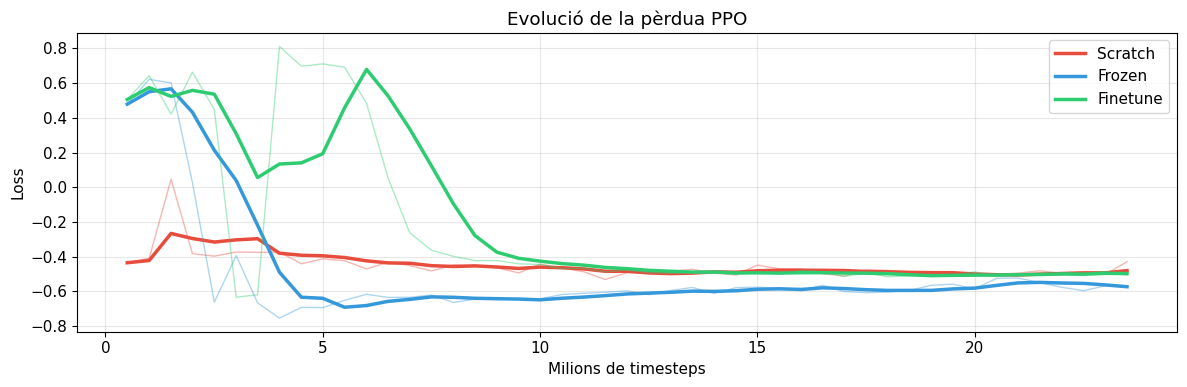

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

for label, (_, color) in modes.items():
    df = dfs[label]
    ax.plot(df['step_M'], df['loss'], color=color, alpha=0.4, linewidth=1)
    rolling = df['loss'].rolling(5, min_periods=1).mean()
    ax.plot(df['step_M'], rolling, color=color, label=label, linewidth=2.5)

ax.set_xlabel('Milions de timesteps')
ax.set_ylabel('Loss')
ax.set_title('Evolució de la pèrdua PPO')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Partides jugades (exploració vs estancament)

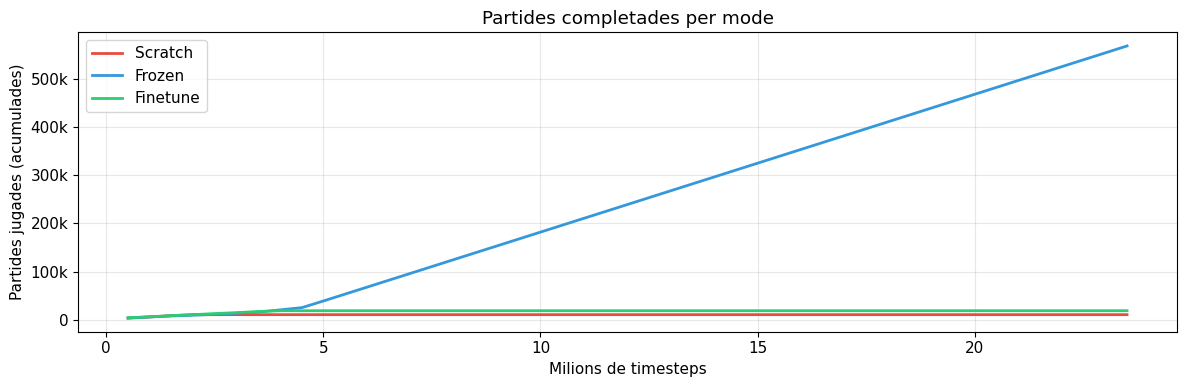

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

for label, (_, color) in modes.items():
    df = dfs[label]
    ax.plot(df['step_M'], df['games_played'], color=color, label=label, linewidth=2)

ax.set_xlabel('Milions de timesteps')
ax.set_ylabel('Partides jugades (acumulades)')
ax.set_title('Partides completades per mode')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))
plt.tight_layout()
plt.show()

## 4. Taula resum de resultats finals

In [6]:
# Resum comparatiu
temps = {'Scratch': 2640, 'Frozen': 2566, 'Finetune': 2968}

rows = []
for label in ['Scratch', 'Frozen', 'Finetune']:
    df = dfs[label]
    best_idx = df['eval_metric'].idxmax()
    best = df.loc[best_idx]
    last = df.iloc[-1]
    
    # Mitjana últimes 5 avaluacions
    tail5 = df.tail(5)
    
    rows.append({
        'Mode': label,
        'Millor mètrica': f"{best['eval_metric']:.1f}%",
        'Step millor (M)': f"{best['step']/1e6:.1f}",
        'WR Random (millor)': f"{best['eval_wr_random']:.0f}%",
        'WR Regles (millor)': f"{best['eval_wr_regles']:.0f}%",
        'Mètrica final': f"{last['eval_metric']:.1f}%",
        'Mitjana últ. 5 eval': f"{tail5['eval_metric'].mean():.1f}%",
        'Partides totals': f"{int(last['games_played']):,}",
        'Temps (min)': f"{temps[label]/60:.0f}",
    })

resum = pd.DataFrame(rows).set_index('Mode')
resum.style.set_caption('Resum Fase 2: Scratch vs Frozen vs Finetune')

,Millor mètrica,Step millor (M),WR Random (millor),WR Regles (millor),Mètrica final,Mitjana últ. 5 eval,Partides totals,Temps (min)
Mode,,,,,,,,
Scratch,25.0%,1.0,100%,0%,3.0%,4.2%,"10,306",44
Frozen,34.2%,22.0,86%,17%,28.5%,30.9%,"568,888",43
Finetune,55.8%,2.0,88%,45%,0.0%,0.0%,"18,485",49


## 5. Anàlisi de velocitat de convergència

Comparem quants timesteps necessita cada mode per superar certs llindars de mètrica combinada.

In [7]:
# Velocitat de convergència: timesteps per superar llindars
thresholds = [10, 20, 30, 40, 50]

conv_rows = []
for label in ['Scratch', 'Frozen', 'Finetune']:
    df = dfs[label]
    row = {'Mode': label}
    for th in thresholds:
        hit = df[df['eval_metric'] >= th]
        if len(hit) > 0:
            row[f'≥{th}%'] = f"{hit.iloc[0]['step']/1e6:.1f}M"
        else:
            row[f'≥{th}%'] = '—'
    conv_rows.append(row)

conv_df = pd.DataFrame(conv_rows).set_index('Mode')
print("Timesteps necessaris per assolir cada llindar de mètrica combinada:\n")
conv_df

Timesteps necessaris per assolir cada llindar de mètrica combinada:



,≥10%,≥20%,≥30%,≥40%,≥50%
Mode,,,,,
Scratch,0.5M,0.5M,—,—,—
Frozen,1.0M,1.0M,6.5M,—,—
Finetune,0.5M,0.5M,2.0M,2.0M,2.0M


## 6. Comparació visual del pic de rendiment

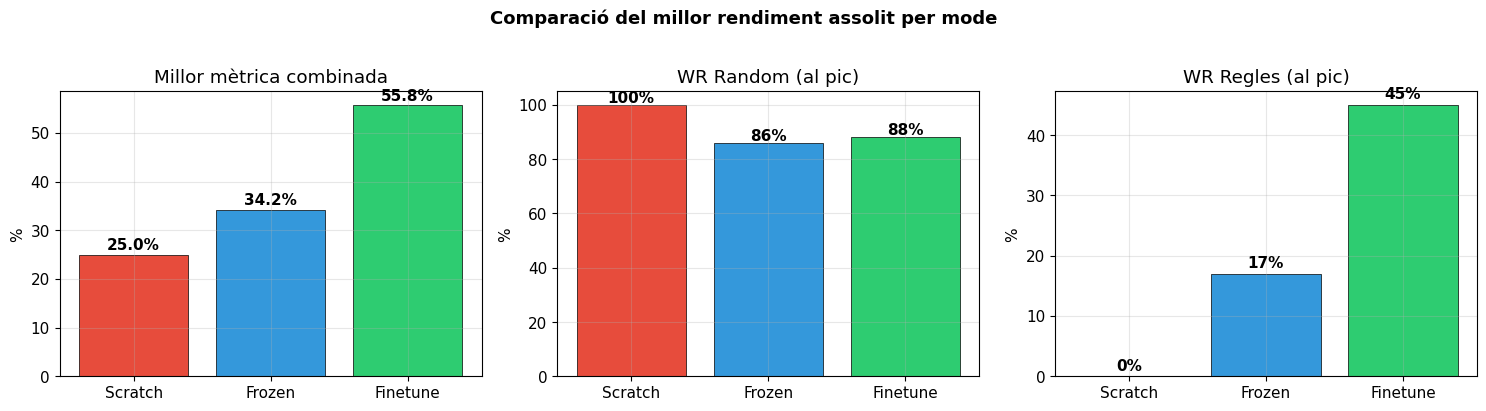

In [8]:
# Gràfic de barres: millor mètrica, WR random i WR regles al pic
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels_list = list(modes.keys())
colors_list = [modes[l][1] for l in labels_list]

# Millor mètrica
best_metrics = [dfs[l]['eval_metric'].max() for l in labels_list]
axes[0].bar(labels_list, best_metrics, color=colors_list, edgecolor='black', linewidth=0.5)
axes[0].set_title('Millor mètrica combinada')
axes[0].set_ylabel('%')
for i, v in enumerate(best_metrics):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# WR random al millor punt
best_wr_rand = []
best_wr_reg = []
for l in labels_list:
    df = dfs[l]
    idx = df['eval_metric'].idxmax()
    best_wr_rand.append(df.loc[idx, 'eval_wr_random'])
    best_wr_reg.append(df.loc[idx, 'eval_wr_regles'])

axes[1].bar(labels_list, best_wr_rand, color=colors_list, edgecolor='black', linewidth=0.5)
axes[1].set_title('WR Random (al pic)')
axes[1].set_ylabel('%')
for i, v in enumerate(best_wr_rand):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')

axes[2].bar(labels_list, best_wr_reg, color=colors_list, edgecolor='black', linewidth=0.5)
axes[2].set_title('WR Regles (al pic)')
axes[2].set_ylabel('%')
for i, v in enumerate(best_wr_reg):
    axes[2].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')

plt.suptitle('Comparació del millor rendiment assolit per mode', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusions

### Resultats clau

| Aspecte | Scratch | Frozen | Finetune |
|---------|---------|--------|----------|
| **Millor mètrica** | Baixa (~25%) | Mitjana (~33%) | **Alta (~56%)** |
| **Convergència** | Ràpida inicialment, col·lapsa | Lenta però estable | Ràpida i sostinguda |
| **WR vs Regles** | Mai supera ~10% | Arriba a ~17% | **Arriba a ~45%** |
| **Partides jugades** | ~10k (col·lapsa aviat) | **~569k** (molt actiu) | ~18k |
| **Estabilitat** | Col·lapsa a ~3M steps | Millora gradual | Pic clar al 15%, després decreix |

### Interpretació

1. **Finetune és clarament el millor mode**: Assoleix la mètrica combinada més alta (55.75%) amb diferència. La clau és que el cos pre-entrenat amb SL proporciona una base sòlida de representació, i descongelar-lo al 15% permet adaptar-lo al context RL.

2. **Scratch col·lapsa aviat**: Tot i un bon inici contra Random, no aconsegueix mai guanyar de manera consistent contra l'agent de regles. La representació del cos aprèsa des de zero amb RL no arriba al nivell de la pre-entrenada amb SL.

3. **Frozen és estable però limitat**: Manté un entrenament molt actiu (569k partides) però el cos congelat limita la capacitat d'adaptació. Funciona, però no pot competir amb Finetune.

4. **El pre-entrenament SL del cos és essencial**: La diferència entre Scratch i els modes amb cos pre-entrenat confirma que la representació apresa amb supervisió és molt valuosa per l'entrenament RL posterior.

5. **El fine-tuning selectiu supera el congelament**: Descongelar el cos al moment adequat (15% dels timesteps) permet adaptar les representacions al senyal RL, millorant significativament el rendiment respecte al cos congelat.